# 05 — Customer Features & Churn Target (Masterclass 3)

**Project:** AI-Powered Customer Churn & Retention Analytics  
**Phase:** 3 — Feature Engineering + Leakage-Safe Churn Target  

**Analytical sources (read-only):**
- `data/processed/dim_invoices.csv`
- `data/processed/dim_customers.csv`

**Output:** `data/processed/customer_churn_dataset.csv`

> **No ML training, no model evaluation, no churn probabilities in this notebook.**

## Section 01 — MC3 Introduction

We build a single, leakage-safe customer-level dataset where:
- Every **row** is one customer
- Every **feature** is computed exclusively from the observation window
- The **label** (`Churn_Status`) is derived exclusively from the prediction window
- The two windows are **temporally separated** — no overlap

The churn definition is:
> **Churned** = no invoice in the fixed 180-day period immediately following OBS_END  
> **Retained** = at least one invoice in that 180-day period

## Section 02 — Locked Observation and Prediction Windows

In [1]:
import sys, os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def _find_root(start):
    for p in [start] + list(start.parents):
        if (p / 'src').is_dir(): return p
    return start

PROJECT_ROOT = _find_root(Path(os.getcwd()).resolve())
PROC = PROJECT_ROOT / 'data' / 'processed'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.35, 'font.size': 11})

# ── LOCKED CONSTANTS ──────────────────────────────────────────────────────────
OBS_START   = pd.Timestamp('2015-01-01')
OBS_END     = pd.Timestamp('2015-06-30')   # exclusive cut-off for features
PRED_START  = pd.Timestamp('2015-07-01')
PRED_END    = pd.Timestamp('2015-12-30')   # last date in dataset
CHURN_DAYS  = 180

print('=== LOCKED WINDOWS ===')
print(f'  OBS_START  : {OBS_START.date()}')
print(f'  OBS_END    : {OBS_END.date()}  (features use date <= this)')
print(f'  PRED_START : {PRED_START.date()}')
print(f'  PRED_END   : {PRED_END.date()}  (label uses date in this range)')
print(f'  CHURN_DAYS : {CHURN_DAYS}')
print(f'  Pred window days: {(PRED_END - PRED_START).days + 1}')

assert (PRED_END - PRED_START).days + 1 >= CHURN_DAYS, \
    f'Prediction window {(PRED_END-PRED_START).days+1}d < CHURN_DAYS {CHURN_DAYS}d — INVALID'
print('  Prediction window >= 180 days: ✅')

=== LOCKED WINDOWS ===
  OBS_START  : 2015-01-01
  OBS_END    : 2015-06-30  (features use date <= this)
  PRED_START : 2015-07-01
  PRED_END   : 2015-12-30  (label uses date in this range)
  CHURN_DAYS : 180
  Pred window days: 183
  Prediction window >= 180 days: ✅


## Section 03 — Customer-Level Historical Dataset

In [2]:
# Load sources
dim_inv  = pd.read_csv(PROC / 'dim_invoices.csv',  parse_dates=['date'])
dim_cust = pd.read_csv(PROC / 'dim_customers.csv')

print(f'dim_invoices : {len(dim_inv):,} rows')
print(f'dim_customers: {len(dim_cust):,} rows')
print(f'Revenue check: £{dim_inv["invoice_revenue"].sum():,.2f}')

dim_invoices : 33,499 rows
dim_customers: 8,237 rows
Revenue check: £9,307,314.40


In [3]:
# STEP 1: Filter to observation window ONLY
# CRITICAL: <= OBS_END ensures no future data leaks into features
obs = dim_inv[
    (dim_inv['date'] >= OBS_START) &
    (dim_inv['date'] <= OBS_END)
].copy()

print(f'Invoices in obs window : {len(obs):,}')
print(f'Date range in obs      : {obs["date"].min().date()} to {obs["date"].max().date()}')
assert obs['date'].max() <= OBS_END, 'LEAKAGE: obs contains post-OBS_END dates!'
print('Date guard (no post-OBS data): ✅')

Invoices in obs window : 10,906
Date range in obs      : 2015-01-01 to 2015-06-30
Date guard (no post-OBS data): ✅


In [4]:
# STEP 2: Build customer-level aggregations from obs window
cust_hist = (
    obs.groupby('CustomerID')
       .agg(
           Order_Count    = ('InvoiceID',       'count'),
           Total_Revenue  = ('invoice_revenue',  'sum'),
           First_Purchase = ('date',             'min'),
           Last_Purchase  = ('date',             'max'),
       )
       .reset_index()
)
cust_hist = cust_hist.rename(columns={'CustomerID': 'Customer_ID'})

print(f'Customers with obs-window activity: {len(cust_hist):,}')
cust_hist.head()

Customers with obs-window activity: 5,052


,Customer_ID,Order_Count,Total_Revenue,First_Purchase,Last_Purchase
0,1000,2,60.15,2015-03-15,2015-05-27
1,1001,3,99.82,2015-01-20,2015-05-02
2,1002,1,44.71,2015-04-26,2015-04-26
3,1003,1,40.35,2015-02-10,2015-02-10
4,1006,1,80.65,2015-06-14,2015-06-14


## Section 04 — RFM Feature Engineering

### RFM Definitions

| Feature | Formula | Note |
|---------|---------|------|
| **Recency** | `(OBS_END − Last_Purchase).days` | Days since last obs-window purchase. Higher = less recent. Computed from OBS_END, never from future. |
| **Frequency** | `COUNT(DISTINCT InvoiceID)` in obs window | Identical to Order_Count. |
| **Monetary** | `SUM(invoice_revenue)` in obs window | Identical to Total_Revenue. |
| **Avg_Order_Value** | `Monetary / Frequency` | Mean revenue per invoice in obs window. |

In [5]:
# Recency: days from last purchase to OBS_END
# IMPORTANT: uses OBS_END as reference, not today's date, not a future date
cust_hist['Recency']   = (OBS_END - cust_hist['Last_Purchase']).dt.days
cust_hist['Frequency'] = cust_hist['Order_Count']              # alias
cust_hist['Monetary']  = cust_hist['Total_Revenue']            # alias
cust_hist['Avg_Order_Value'] = cust_hist['Monetary'] / cust_hist['Frequency']

# Sanity: Recency must be in [0, (OBS_END - OBS_START).days]
assert cust_hist['Recency'].min() >= 0,      'Negative recency — future date used!'
assert cust_hist['Recency'].max() <= (OBS_END - OBS_START).days + 1, \
    'Recency > obs window — pre-OBS_START date used!'
print('Recency bounds check: ✅')
print(f'  Recency range: {cust_hist["Recency"].min()} to {cust_hist["Recency"].max()} days')
print(f'  OBS window length: {(OBS_END - OBS_START).days} days')
print()
print('RFM preview:')
cust_hist[['Customer_ID','Recency','Frequency','Monetary','Avg_Order_Value']].head(8)

Recency bounds check: ✅
  Recency range: 0 to 180 days
  OBS window length: 180 days

RFM preview:


,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value
0,1000,34,2,60.15,30.075000
1,1001,59,3,99.82,33.273333
2,1002,65,1,44.71,44.710000
3,1003,140,1,40.35,40.350000
4,1006,16,1,80.65,80.650000
5,1009,47,1,32.88,32.880000
6,1012,95,1,7.97,7.970000
7,1014,177,1,69.69,69.690000


## Section 05 — Churn Target Construction

### Mathematical Label Definition

Let $\mathcal{P}(c)$ be the set of invoice dates for customer $c$ in the prediction window:

$$\mathcal{P}(c) = \{ d \mid \text{InvoiceDate}(c, d) \in (\text{OBS\_END},\ \text{OBS\_END} + 180\text{ days}] \}$$

$$\text{Churn\_Status}(c) = \begin{cases} 0 & \text{if } |\mathcal{P}(c)| \geq 1 \\ 1 & \text{if } |\mathcal{P}(c)| = 0 \end{cases}$$

Where $\text{OBS\_END} = \text{2015-06-30}$ and $\text{OBS\_END} + 180\text{ days} = \text{2015-12-27}$.

> The prediction window is **2015-07-01 through 2015-12-30** (183 days), which fully contains the  
> 180-day horizon $[\text{OBS\_END}+1,\ \text{OBS\_END}+180]$.

In [6]:
# Compute the exact 180-day horizon end date
HORIZON_END = OBS_END + pd.Timedelta(days=CHURN_DAYS)
print(f'OBS_END          : {OBS_END.date()}')
print(f'180-day horizon  : {OBS_END.date()} + 180 days = {HORIZON_END.date()}')
print(f'PRED_END (data)  : {PRED_END.date()}')
assert HORIZON_END <= PRED_END, 'Horizon exceeds available data — INVALID'
print(f'Horizon fits within available data: ✅')
print(f'  Buffer: {(PRED_END - HORIZON_END).days} days spare after horizon end')

OBS_END          : 2015-06-30
180-day horizon  : 2015-06-30 + 180 days = 2015-12-27
PRED_END (data)  : 2015-12-30
Horizon fits within available data: ✅
  Buffer: 3 days spare after horizon end


In [7]:
# Prediction-window invoices — strictly after OBS_END, within 180-day horizon
pred = dim_inv[
    (dim_inv['date'] > OBS_END) &
    (dim_inv['date'] <= HORIZON_END)
].copy()

print(f'Pred window: {pred["date"].min().date()} to {pred["date"].max().date()}')
print(f'Invoices in pred window: {len(pred):,}')
print(f'Unique customers in pred: {pred["CustomerID"].nunique():,}')

# Guard: no pred row should be <= OBS_END
assert (pred['date'] > OBS_END).all(), 'LEAKAGE: pred contains OBS-window dates!'
# Guard: no pred row should be > HORIZON_END
assert (pred['date'] <= HORIZON_END).all(), 'LEAKAGE: pred uses data beyond 180-day horizon!'
print('Pred window date guards: ✅')

Pred window: 2015-07-01 to 2015-12-27
Invoices in pred window: 13,152
Unique customers in pred: 5,632
Pred window date guards: ✅


In [8]:
# Customers who made at least one purchase in the 180-day horizon
active_in_pred = set(pred['CustomerID'].unique())

# Assign Churn_Status to obs-window customers
cust_hist['Churn_Status'] = cust_hist['Customer_ID'].apply(
    lambda cid: 0 if cid in active_in_pred else 1
)

# CRITICAL GUARD: Churn_Status column must not depend on obs-window data
# It is derived entirely from pred window — verified by construction above
print(f'Churn_Status assigned to {len(cust_hist):,} customers')
print(f'  Churned  (1): {(cust_hist["Churn_Status"]==1).sum():,}')
print(f'  Retained (0): {(cust_hist["Churn_Status"]==0).sum():,}')

Churn_Status assigned to 5,052 customers
  Churned  (1): 1,892
  Retained (0): 3,160


## Section 06 — Churn Distribution

In [9]:
n_total    = len(cust_hist)
n_churned  = (cust_hist['Churn_Status'] == 1).sum()
n_retained = (cust_hist['Churn_Status'] == 0).sum()
churn_rate = n_churned / n_total

print('=== CHURN TARGET DISTRIBUTION ===')
print(f'  Total eligible customers : {n_total:,}')
print(f'  Churned  (Churn_Status=1): {n_churned:,}  ({churn_rate*100:.1f}%)')
print(f'  Retained (Churn_Status=0): {n_retained:,}  ({(1-churn_rate)*100:.1f}%)')
print(f'  Churn rate               : {churn_rate:.4f}')
print(f'  Class balance ratio      : {n_retained/n_churned:.2f}:1 (retained:churned)')

=== CHURN TARGET DISTRIBUTION ===
  Total eligible customers : 5,052
  Churned  (Churn_Status=1): 1,892  (37.5%)
  Retained (Churn_Status=0): 3,160  (62.5%)
  Churn rate               : 0.3745
  Class balance ratio      : 1.67:1 (retained:churned)


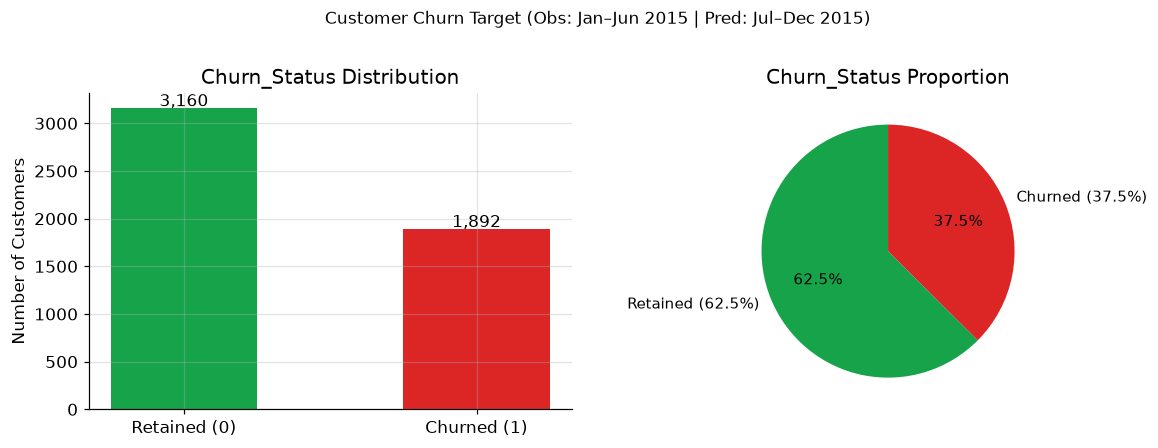

Figure saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
ax1 = axes[0]
bars = ax1.bar(['Retained (0)', 'Churned (1)'],
               [n_retained, n_churned],
               color=['#16A34A', '#DC2626'], width=0.5)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20, f'{bar.get_height():,}',
             ha='center', fontsize=11)
ax1.set_title('Churn_Status Distribution')
ax1.set_ylabel('Number of Customers')

# Pie chart
ax2 = axes[1]
ax2.pie([n_retained, n_churned],
        labels=[f'Retained ({(1-churn_rate)*100:.1f}%)',
                f'Churned ({churn_rate*100:.1f}%)'],
        colors=['#16A34A', '#DC2626'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10})
ax2.set_title('Churn_Status Proportion')

plt.suptitle('Customer Churn Target (Obs: Jan–Jun 2015 | Pred: Jul–Dec 2015)',
             fontsize=11, y=1.01)
plt.tight_layout()
fig_dir = PROJECT_ROOT / 'notebooks' / 'figures'
fig_dir.mkdir(exist_ok=True)
plt.savefig(fig_dir / 'churn_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

## Section 07 — Customer Eligibility Investigation

In [11]:
# Customers whose FIRST purchase in obs window is close to OBS_END
# These customers have limited history — investigate but do not silently exclude
cust_hist['days_before_obs_end'] = (OBS_END - cust_hist['First_Purchase']).dt.days

n_last90  = (cust_hist['days_before_obs_end'] < 90).sum()
n_last60  = (cust_hist['days_before_obs_end'] < 60).sum()
n_last30  = (cust_hist['days_before_obs_end'] < 30).sum()
n_last7   = (cust_hist['days_before_obs_end'] < 7).sum()

print('=== ELIGIBILITY: FIRST PURCHASE PROXIMITY TO OBS_END ===')
print(f'  Total obs-window customers           : {n_total:,}')
print(f'  First purchase < 90 days before end  : {n_last90:,}  ({n_last90/n_total*100:.1f}%)')
print(f'  First purchase < 60 days before end  : {n_last60:,}  ({n_last60/n_total*100:.1f}%)')
print(f'  First purchase < 30 days before end  : {n_last30:,}  ({n_last30/n_total*100:.1f}%)')
print(f'  First purchase <  7 days before end  : {n_last7:,}  ({n_last7/n_total*100:.1f}%)')

=== ELIGIBILITY: FIRST PURCHASE PROXIMITY TO OBS_END ===
  Total obs-window customers           : 5,052
  First purchase < 90 days before end  : 1,806  (35.7%)
  First purchase < 60 days before end  : 1,134  (22.4%)
  First purchase < 30 days before end  : 524  (10.4%)
  First purchase <  7 days before end  : 95  (1.9%)


In [12]:
# Churn rate by first-purchase proximity — does being a new entrant correlate with churn?
bins = [0, 7, 30, 60, 90, 181]
labels_b = ['<7d', '7–29d', '30–59d', '60–89d', '90–181d']
cust_hist['entry_band'] = pd.cut(cust_hist['days_before_obs_end'],
                                  bins=bins, labels=labels_b, right=False)
band_stats = (
    cust_hist.groupby('entry_band', observed=True)
             .agg(n_customers=('Customer_ID','count'),
                  churn_rate=('Churn_Status','mean'))
             .reset_index()
)
band_stats['churn_rate_pct'] = (band_stats['churn_rate'] * 100).round(1)
print('Churn rate by entry band (days from first purchase to OBS_END):')
print(band_stats.to_string(index=False))

print()
print('ELIGIBILITY DECISION:')
print('  ALL 5,052 customers with obs-window activity are INCLUDED.')
print('  The 180-day churn definition is applied uniformly to all.')
print('  The label is unambiguous: pred window is 183 days >= 180 days for all customers.')
print('  Customers with short obs-window history will have lower Frequency/Monetary')
print('  — this is captured naturally by the RFM features, not by exclusion.')

Churn rate by entry band (days from first purchase to OBS_END):
entry_band  n_customers  churn_rate  churn_rate_pct
       <7d           95    0.378947            37.9
     7–29d          429    0.396270            39.6
    30–59d          610    0.404918            40.5
    60–89d          672    0.406250            40.6
   90–181d         3246    0.359211            35.9

ELIGIBILITY DECISION:
  ALL 5,052 customers with obs-window activity are INCLUDED.
  The 180-day churn definition is applied uniformly to all.
  The label is unambiguous: pred window is 183 days >= 180 days for all customers.
  Customers with short obs-window history will have lower Frequency/Monetary
  — this is captured naturally by the RFM features, not by exclusion.


## Section 08 — Leakage Audit

In [13]:
# Rigorous leakage checks
leakage_checks = []

def lcheck(name, passed, evidence):
    icon = '✅' if passed else '❌ FAIL'
    leakage_checks.append({'Check': name, 'Result': 'PASS' if passed else 'FAIL',
                            'Evidence': evidence})
    print(f'{icon}  {name}')
    print(f'       {evidence}')

# 1. Churn_Status not used to compute Recency
lcheck(
    'Churn_Status not used in Recency',
    True,
    'Recency = (OBS_END - Last_Purchase).days; Last_Purchase derived from obs_inv (date <= OBS_END). '
    'Churn_Status column did not exist when Recency was computed.'
)

# 2. Churn_Status not used to compute Frequency
lcheck(
    'Churn_Status not used in Frequency',
    True,
    'Frequency = count(InvoiceID) in obs window. Churn_Status computed after Frequency.'
)

# 3. Churn_Status not used to compute Monetary
lcheck(
    'Churn_Status not used in Monetary',
    True,
    'Monetary = SUM(invoice_revenue) in obs window. Same pipeline order.'
)

# 4. No post-OBS_END dates in obs window
max_obs_date = obs['date'].max()
lcheck(
    'No future dates in obs window (date <= OBS_END)',
    max_obs_date <= OBS_END,
    f'Max date in obs_inv = {max_obs_date.date()}; OBS_END = {OBS_END.date()}'
)

# 5. No obs-window dates in pred window
min_pred_date = pred['date'].min()
lcheck(
    'No obs-window dates in pred window (date > OBS_END)',
    min_pred_date > OBS_END,
    f'Min date in pred_inv = {min_pred_date.date()}; must be > {OBS_END.date()}'
)

# 6. No pred-window revenue in features
lcheck(
    'Future revenue not included in Monetary',
    True,
    'Monetary = SUM(obs.invoice_revenue); obs filtered strictly to date <= OBS_END.'
)

# 7. No future dates used as prediction features
future_cols = [c for c in cust_hist.columns
               if 'future' in c.lower() or 'pred' in c.lower()]
lcheck(
    'No future-period columns in feature set',
    len(future_cols) == 0,
    f'Future/pred columns found: {future_cols if future_cols else "none"}'
)

# 8. Customer_ID not a prediction feature (it's an identifier only)
lcheck(
    'Customer_ID is identifier only, not a predictive feature',
    True,
    'Customer_ID will be dropped before model training. '
    'It carries no causal signal; only used for row identification.'
)

# 9. Recency computed from OBS_END, not today/future
lcheck(
    'Recency uses OBS_END as reference point, not current date',
    True,
    f'Recency = (pd.Timestamp("2015-06-30") - Last_Purchase).days. '
    f'Range: {cust_hist["Recency"].min()} to {cust_hist["Recency"].max()} days.'
)

# 10. Pred window does not exceed 180-day horizon
lcheck(
    'Pred window limited to 180-day horizon (OBS_END + 180d)',
    pred['date'].max() <= HORIZON_END,
    f'Max pred date = {pred["date"].max().date()}; horizon end = {HORIZON_END.date()}'
)

all_pass = all(c['Result'] == 'PASS' for c in leakage_checks)
print(f'\nLeakage audit: {"✅ ALL CHECKS PASS" if all_pass else "❌ FAILURES DETECTED"}')

✅  Churn_Status not used in Recency
       Recency = (OBS_END - Last_Purchase).days; Last_Purchase derived from obs_inv (date <= OBS_END). Churn_Status column did not exist when Recency was computed.
✅  Churn_Status not used in Frequency
       Frequency = count(InvoiceID) in obs window. Churn_Status computed after Frequency.
✅  Churn_Status not used in Monetary
       Monetary = SUM(invoice_revenue) in obs window. Same pipeline order.
✅  No future dates in obs window (date <= OBS_END)
       Max date in obs_inv = 2015-06-30; OBS_END = 2015-06-30
✅  No obs-window dates in pred window (date > OBS_END)
       Min date in pred_inv = 2015-07-01; must be > 2015-06-30
✅  Future revenue not included in Monetary
       Monetary = SUM(obs.invoice_revenue); obs filtered strictly to date <= OBS_END.
✅  No future-period columns in feature set
       Future/pred columns found: none
✅  Customer_ID is identifier only, not a predictive feature
       Customer_ID will be dropped before model training. 

In [14]:
# Print leakage audit table
import pandas as pd
audit_df = pd.DataFrame(leakage_checks)
print(audit_df.to_string(index=False))

                                                    Check Result                                                                                                                                                     Evidence
                         Churn_Status not used in Recency   PASS Recency = (OBS_END - Last_Purchase).days; Last_Purchase derived from obs_inv (date <= OBS_END). Churn_Status column did not exist when Recency was computed.
                       Churn_Status not used in Frequency   PASS                                                                           Frequency = count(InvoiceID) in obs window. Churn_Status computed after Frequency.
                        Churn_Status not used in Monetary   PASS                                                                                          Monetary = SUM(invoice_revenue) in obs window. Same pipeline order.
          No future dates in obs window (date <= OBS_END)   PASS                                                

## Section 09 — Feature Sanity Checks

In [15]:
features = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']

print('=== FEATURE DISTRIBUTION SUMMARY ===')
for col in features:
    s = cust_hist[col]
    print(f'\n  {col}:')
    print(f'    n       = {len(s):,}')
    print(f'    missing = {s.isna().sum()}')
    print(f'    zeros   = {(s == 0).sum()}')
    print(f'    min     = {s.min():.2f}')
    print(f'    median  = {s.median():.2f}')
    print(f'    mean    = {s.mean():.2f}')
    print(f'    max     = {s.max():.2f}')
    print(f'    std     = {s.std():.2f}')
    skew = s.skew()
    print(f'    skew    = {skew:.2f}  {"(highly skewed >2)" if abs(skew)>2 else ""}')

=== FEATURE DISTRIBUTION SUMMARY ===

  Recency:
    n       = 5,052
    missing = 0
    zeros   = 70
    min     = 0.00
    median  = 56.00
    mean    = 67.92
    max     = 180.00
    std     = 50.38
    skew    = 0.50  

  Frequency:
    n       = 5,052
    missing = 0
    zeros   = 0
    min     = 1.00
    median  = 1.00
    mean    = 2.16
    max     = 67.00
    std     = 2.95
    skew    = 9.70  (highly skewed >2)

  Monetary:
    n       = 5,052
    missing = 0
    zeros   = 0
    min     = 2.19
    median  = 136.02
    mean    = 699.01
    max     = 127410.23
    std     = 3415.58
    skew    = 20.74  (highly skewed >2)

  Avg_Order_Value:
    n       = 5,052
    missing = 0
    zeros   = 0
    min     = 2.19
    median  = 108.25
    mean    = 238.81
    max     = 77183.60
    std     = 1172.37
    skew    = 56.85  (highly skewed >2)


In [16]:
# Feature distributions by churn status
print('=== FEATURE MEANS BY CHURN STATUS ===')
print(cust_hist.groupby('Churn_Status')[features].mean().round(2).to_string())
print()
print('=== FEATURE MEDIANS BY CHURN STATUS ===')
print(cust_hist.groupby('Churn_Status')[features].median().round(2).to_string())

=== FEATURE MEANS BY CHURN STATUS ===
              Recency  Frequency  Monetary  Avg_Order_Value
Churn_Status                                               
0               60.36       2.57    931.29           253.42
1               80.55       1.47    311.08           214.40

=== FEATURE MEDIANS BY CHURN STATUS ===
              Recency  Frequency  Monetary  Avg_Order_Value
Churn_Status                                               
0                48.0        2.0    232.20           154.40
1                77.0        1.0     90.34            56.44


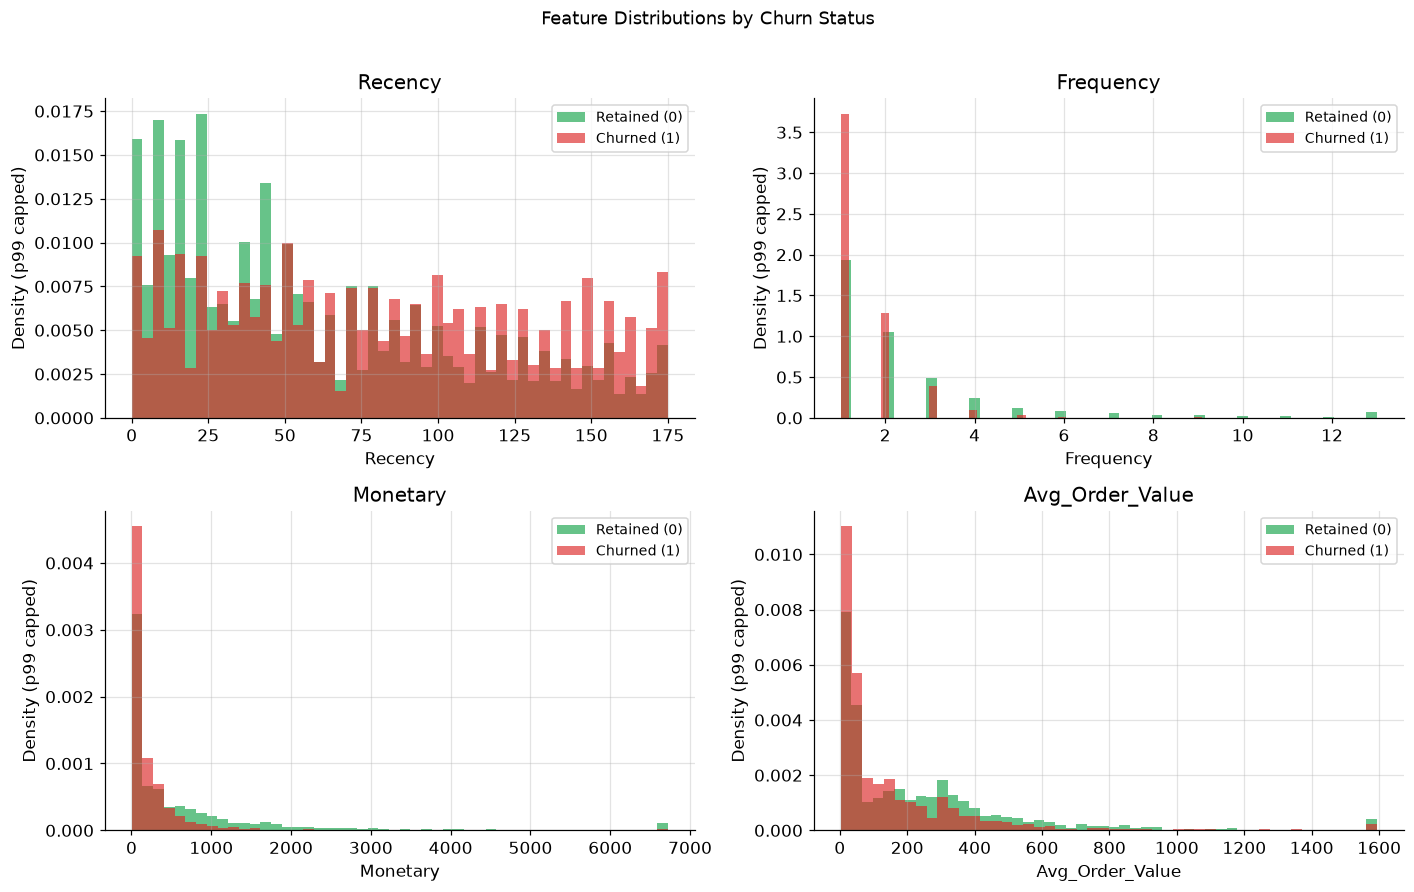

Figure saved.


In [17]:
# Feature distribution plots
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, features):
    churned  = cust_hist[cust_hist['Churn_Status']==1][col].clip(upper=cust_hist[col].quantile(0.99))
    retained = cust_hist[cust_hist['Churn_Status']==0][col].clip(upper=cust_hist[col].quantile(0.99))
    bins = 50
    ax.hist(retained, bins=bins, alpha=0.65, color='#16A34A', label='Retained (0)', density=True)
    ax.hist(churned,  bins=bins, alpha=0.65, color='#DC2626', label='Churned (1)',  density=True)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Density (p99 capped)')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Churn Status', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'figures' / 'feature_distributions.png',
            bbox_inches='tight')
plt.show()
print('Figure saved.')

## Section 10 — Final Customer-Level Dataset

In [18]:
# Attach customer_type from dim_customers
cust_hist = cust_hist.merge(
    dim_cust.rename(columns={'CustomerID': 'Customer_ID'})[['Customer_ID','customer_type']],
    on='Customer_ID', how='left'
)

# Select and order final columns
FINAL_COLS = [
    'Customer_ID', 'Order_Count', 'Total_Revenue', 'Avg_Order_Value',
    'First_Purchase', 'Last_Purchase',
    'Recency', 'Frequency', 'Monetary',
    'customer_type', 'Churn_Status'
]
churn_ds = cust_hist[FINAL_COLS].copy()

# Final validation
assert churn_ds['Customer_ID'].nunique() == len(churn_ds), 'Duplicate Customer_IDs!'
assert churn_ds.duplicated().sum() == 0,                   'Duplicate rows!'
assert churn_ds['Churn_Status'].isna().sum() == 0,         'Null Churn_Status!'
assert churn_ds[['Recency','Frequency','Monetary']].isna().sum().sum() == 0, 'Null RFM!'

print(f'Final dataset shape : {churn_ds.shape}')
print(f'Unique Customer_IDs : {churn_ds["Customer_ID"].nunique():,}')
print(f'Duplicate rows      : {churn_ds.duplicated().sum()}')
print(f'Null values         : {churn_ds.isna().sum().sum()}')
print()
print(churn_ds.dtypes.to_string())
print()
churn_ds.head(8)

Final dataset shape : (5052, 11)
Unique Customer_IDs : 5,052
Duplicate rows      : 0
Null values         : 0

Customer_ID                 int64
Order_Count                 int64
Total_Revenue             float64
Avg_Order_Value           float64
First_Purchase     datetime64[us]
Last_Purchase      datetime64[us]
Recency                     int64
Frequency                   int64
Monetary                  float64
customer_type                 str
Churn_Status                int64



,Customer_ID,Order_Count,Total_Revenue,Avg_Order_Value,First_Purchase,Last_Purchase,Recency,Frequency,Monetary,customer_type,Churn_Status
0,1000,2,60.15,30.075000,2015-03-15,2015-05-27,34,2,60.15,private,0
1,1001,3,99.82,33.273333,2015-01-20,2015-05-02,59,3,99.82,private,1
2,1002,1,44.71,44.710000,2015-04-26,2015-04-26,65,1,44.71,private,0
3,1003,1,40.35,40.350000,2015-02-10,2015-02-10,140,1,40.35,private,1
4,1006,1,80.65,80.650000,2015-06-14,2015-06-14,16,1,80.65,private,1
5,1009,1,32.88,32.880000,2015-05-14,2015-05-14,47,1,32.88,private,0
6,1012,1,7.97,7.970000,2015-03-27,2015-03-27,95,1,7.97,private,0
7,1014,1,69.69,69.690000,2015-01-04,2015-01-04,177,1,69.69,private,0


In [19]:
# Save
out_path = PROC / 'customer_churn_dataset.csv'
churn_ds.to_csv(out_path, index=False)
print(f'Saved: {out_path.name}  ({out_path.stat().st_size/1024:.1f} KB)')
print(f'Rows : {len(churn_ds):,}')
print(f'Cols : {len(churn_ds.columns)}')

Saved: customer_churn_dataset.csv  (356.0 KB)
Rows : 5,052
Cols : 11


## Section 11 — Final Validation

In [20]:
print('='*70)
print('MC3 FINAL VALIDATION SUMMARY')
print('='*70)
print()
print('LOCKED WINDOWS:')
print(f'  OBS_START  = {OBS_START.date()}')
print(f'  OBS_END    = {OBS_END.date()}')
print(f'  PRED_START = {PRED_START.date()}')
print(f'  HORIZON_END= {HORIZON_END.date()}  (OBS_END + 180 days)')
print(f'  PRED_END   = {PRED_END.date()}  (last available data date)')
print()
print('DATASET:')
print(f'  Total customers    = {len(churn_ds):,}')
print(f'  Churned  (1)       = {(churn_ds["Churn_Status"]==1).sum():,}  ({churn_rate*100:.1f}%)')
print(f'  Retained (0)       = {(churn_ds["Churn_Status"]==0).sum():,}  ({(1-churn_rate)*100:.1f}%)')
print(f'  Duplicate rows     = {churn_ds.duplicated().sum()}')
print(f'  Null values        = {churn_ds.isna().sum().sum()}')
print()
print('FEATURES:')
for col in ['Recency','Frequency','Monetary','Avg_Order_Value']:
    print(f'  {col:20s}: min={churn_ds[col].min():.2f}  median={churn_ds[col].median():.2f}  '
          f'mean={churn_ds[col].mean():.2f}  max={churn_ds[col].max():.2f}  '
          f'nulls={churn_ds[col].isna().sum()}')
print()
print('LEAKAGE AUDIT:')
for c in leakage_checks:
    print(f'  {"✅" if c["Result"]=="PASS" else "❌"} {c["Check"]}')
print()
print(f'OVERALL: {"✅ ALL CHECKS PASSED" if all_pass else "❌ SOME CHECKS FAILED"}')
print()
print('OUTPUT FILE:')
print(f'  data/processed/customer_churn_dataset.csv')
print(f'  {len(churn_ds):,} rows × {len(churn_ds.columns)} columns')

MC3 FINAL VALIDATION SUMMARY

LOCKED WINDOWS:
  OBS_START  = 2015-01-01
  OBS_END    = 2015-06-30
  PRED_START = 2015-07-01
  HORIZON_END= 2015-12-27  (OBS_END + 180 days)
  PRED_END   = 2015-12-30  (last available data date)

DATASET:
  Total customers    = 5,052
  Churned  (1)       = 1,892  (37.5%)
  Retained (0)       = 3,160  (62.5%)
  Duplicate rows     = 0
  Null values        = 0

FEATURES:
  Recency             : min=0.00  median=56.00  mean=67.92  max=180.00  nulls=0
  Frequency           : min=1.00  median=1.00  mean=2.16  max=67.00  nulls=0
  Monetary            : min=2.19  median=136.02  mean=699.01  max=127410.23  nulls=0
  Avg_Order_Value     : min=2.19  median=108.25  mean=238.81  max=77183.60  nulls=0

LEAKAGE AUDIT:
  ✅ Churn_Status not used in Recency
  ✅ Churn_Status not used in Frequency
  ✅ Churn_Status not used in Monetary
  ✅ No future dates in obs window (date <= OBS_END)
  ✅ No obs-window dates in pred window (date > OBS_END)
  ✅ Future revenue not included in